Librerías

In [1]:
import yfinance as yf
import pandas as pd

Descarga de datos

In [3]:
# Descargar datos históricos del S&P 500
sp500 = yf.download(
    "^GSPC",
    start="2016-06-01",
    end="2026-06-02",  # end es exclusivo
    auto_adjust=False,
    progress=False
)

# Visualizar las primeras filas
print(sp500.head())

# Visualizar las últimas filas
print(sp500.tail())

# Guardar en CSV
#sp500.to_csv("sp500_2016_2026.csv")

print(f"\nNúmero de observaciones: {len(sp500)}")

Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date                                                                          
2016-06-01  2099.330078  2099.330078  2100.969971  2085.100098  2093.939941   
2016-06-02  2105.260010  2105.260010  2105.260010  2088.590088  2097.709961   
2016-06-03  2099.129883  2099.129883  2104.070068  2085.360107  2104.070068   
2016-06-06  2109.409912  2109.409912  2113.360107  2100.830078  2100.830078   
2016-06-07  2112.129883  2112.129883  2119.219971  2110.179932  2110.179932   

Price           Volume  
Ticker           ^GSPC  
Date                    
2016-06-01  3525170000  
2016-06-02  3632720000  
2016-06-03  3627780000  
2016-06-06  3442020000  
2016-06-07  3534730000  
Price         Adj Close        Close         High          Low         Open  \
Ticker            ^GSPC        ^GSPC        ^GSPC        ^GSPC        ^GSPC   
Date     

Análisis exploratorio


Dimensiones:
(2514, 6)

Tipos de datos:
Price
Adj Close    float64
Close        float64
High         float64
Low          float64
Open         float64
Volume         int64
dtype: object

Valores faltantes:
Price
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

Estadísticas descriptivas:
Price    Adj Close        Close         High          Low         Open  \
count  2514.000000  2514.000000  2514.000000  2514.000000  2514.000000   
mean   3974.049478  3974.049478  3994.264366  3950.686741  3973.201130   
std    1386.947335  1386.947335  1392.831366  1379.527559  1386.300501   
min    2000.540039  2000.540039  2031.449951  1991.680054  2006.670044   
25%    2783.090027  2783.090027  2795.249939  2766.707397  2784.855042   
50%    3874.385010  3874.385010  3904.405029  3838.994995  3872.554932   
75%    4701.397461  4701.397461  4724.129883  4682.154907  4703.895020   
max    7599.959961  7599.959961  7617.660156  7563.549805  7582.

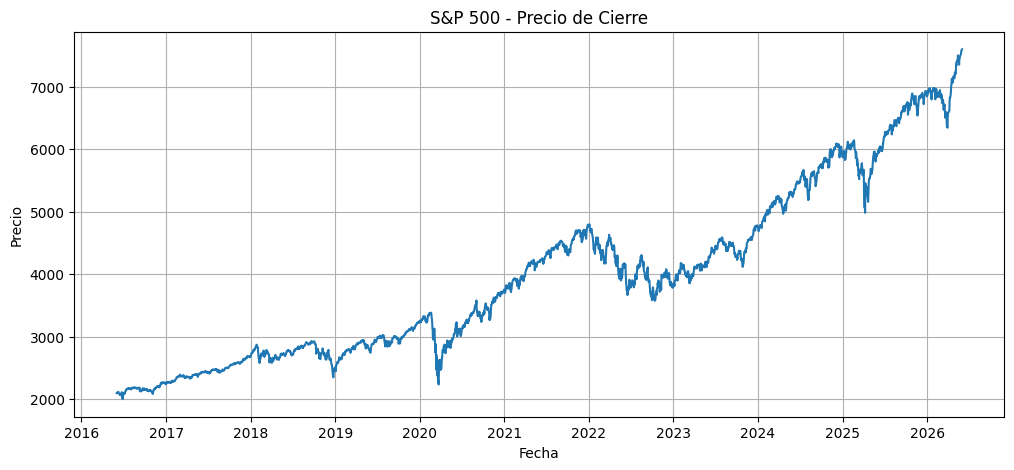

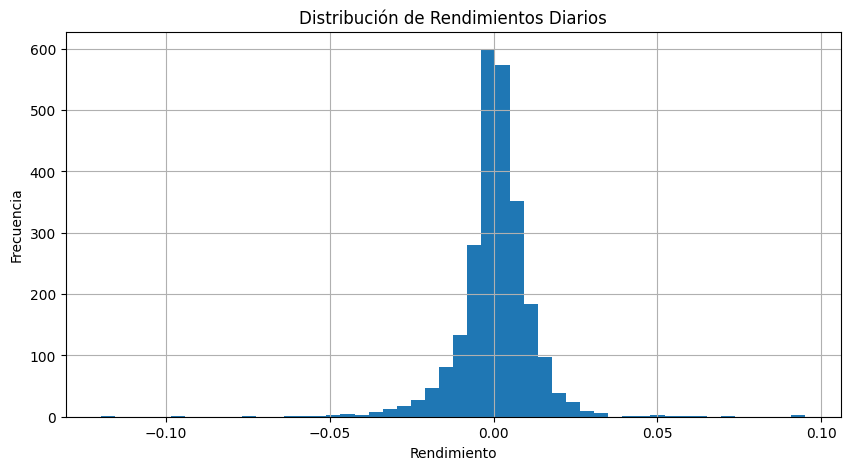

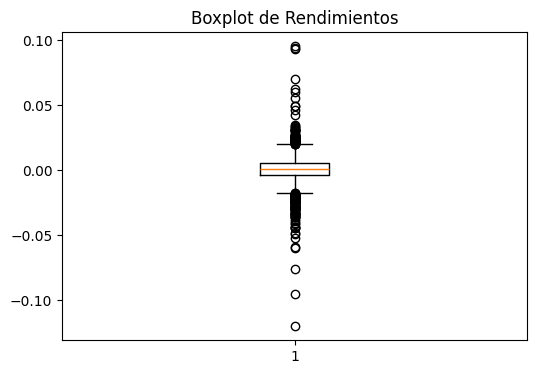

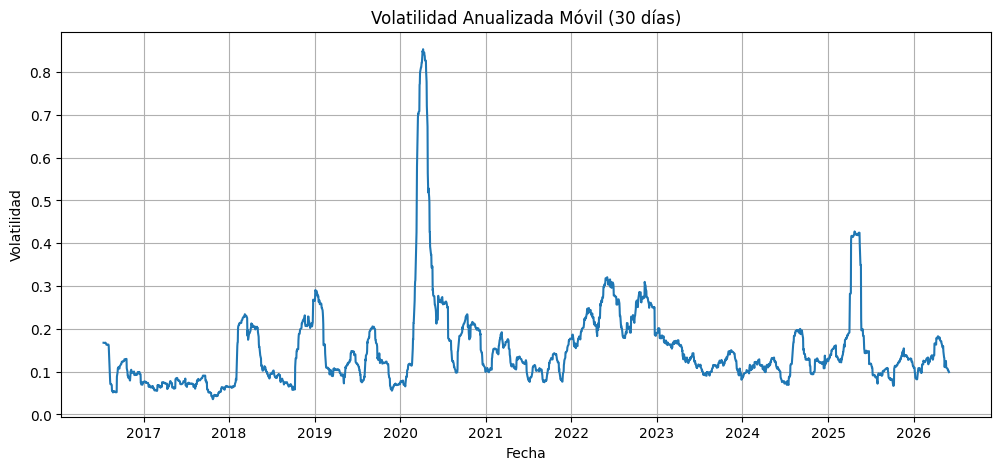

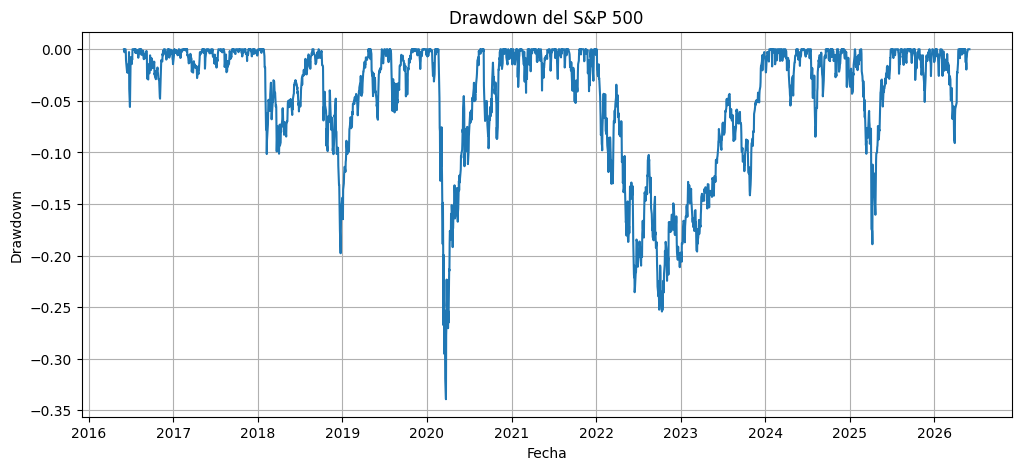


Máximo Drawdown:
-33.92%

Asimetría:
-0.3819985455068371

Curtosis:
15.974201460151495


In [4]:
# Librerías
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# CORRECCIÓN: Aplanar el MultiIndex de yfinance
# ==========================
# Si las columnas tienen múltiples niveles (cambio reciente en yfinance), eliminamos el nivel del ticker
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = sp500.columns.droplevel(1)

# ==========================
# 1. Información general
# ==========================

print("\nDimensiones:")
print(sp500.shape)

print("\nTipos de datos:")
print(sp500.dtypes)

print("\nValores faltantes:")
print(sp500.isnull().sum())

print("\nEstadísticas descriptivas:")
print(sp500.describe())

# ==========================
# 2. Rendimientos diarios
# ==========================

sp500["Return"] = sp500["Close"].pct_change()

print("\nEstadísticas de rendimientos:")
print(sp500["Return"].describe())

# ==========================
# 3. Precio histórico
# ==========================

plt.figure(figsize=(12,5))
plt.plot(sp500.index, sp500["Close"])
plt.title("S&P 500 - Precio de Cierre")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.grid()
plt.show()

# ==========================
# 4. Histograma de retornos
# ==========================

plt.figure(figsize=(10,5))
sp500["Return"].hist(bins=50)
plt.title("Distribución de Rendimientos Diarios")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")
plt.show()

# ==========================
# 5. Boxplot de retornos
# ==========================

plt.figure(figsize=(6,4))
plt.boxplot(sp500["Return"].dropna())
plt.title("Boxplot de Rendimientos")
plt.show()

# ==========================
# 6. Volatilidad móvil
# ==========================

sp500["Vol_30"] = (
    sp500["Return"]
    .rolling(30)
    .std()
    * np.sqrt(252)
)

plt.figure(figsize=(12,5))
plt.plot(sp500.index, sp500["Vol_30"])
plt.title("Volatilidad Anualizada Móvil (30 días)")
plt.xlabel("Fecha")
plt.ylabel("Volatilidad")
plt.grid()
plt.show()

# ==========================
# 7. Máximo Drawdown
# ==========================

cummax = sp500["Close"].cummax()
drawdown = (sp500["Close"] - cummax) / cummax

plt.figure(figsize=(12,5))
plt.plot(sp500.index, drawdown)
plt.title("Drawdown del S&P 500")
plt.xlabel("Fecha")
plt.ylabel("Drawdown")
plt.grid()
plt.show()

print("\nMáximo Drawdown:")
# Ahora drawdown.min() devolverá un número (float) correctamente.
print(f"{drawdown.min():.2%}")

# ==========================
# 8. Asimetría y curtosis
# ==========================

print("\nAsimetría:")
print(sp500["Return"].skew())

print("\nCurtosis:")
print(sp500["Return"].kurtosis())

Indicadores técnicos

In [5]:
import ta
# ==========================
# RSI (14 días)
# ==========================
sp500["RSI"] = ta.momentum.RSIIndicator(
    close=sp500["Close"],
    window=14
).rsi()

# ==========================
# MACD
# ==========================
macd = ta.trend.MACD(
    close=sp500["Close"],
    window_fast=12,
    window_slow=26,
    window_sign=9
)

sp500["MACD"] = macd.macd()
sp500["MACD_SIGNAL"] = macd.macd_signal()
sp500["MACD_HIST"] = macd.macd_diff()

# ==========================
# Momentum (10 días)
# ==========================
sp500["Momentum"] = (
    sp500["Close"] - sp500["Close"].shift(10)
)

# ==========================
# ATR (14 días)
# ==========================
sp500["ATR"] = ta.volatility.AverageTrueRange(
    high=sp500["High"],
    low=sp500["Low"],
    close=sp500["Close"],
    window=14
).average_true_range()

# ==========================
# Variación porcentual del volumen
# ==========================
sp500["Volume_Pct_Change"] = (
    sp500["Volume"].pct_change() * 100
)

# Eliminar NaN
sp500 = sp500.dropna()

print(sp500[
    [
        "RSI",
        "MACD",
        "Momentum",
        "ATR",
        "Volume_Pct_Change"
    ]
].head())

Price             RSI       MACD   Momentum        ATR  Volume_Pct_Change
Date                                                                     
2016-07-19  65.187585  20.805454  75.229980  19.911181          -1.361442
2016-07-20  67.139875  22.046929  73.290039  19.335372           8.203912
2016-07-21  63.863088  22.142129  67.270020  19.012135           7.068801
2016-07-22  66.101013  22.750946  45.130127  18.501991         -12.085841
2016-07-25  63.296720  22.446157  31.320068  18.114712           1.123283


## Indicadores técnicos

- **RSI (Relative Strength Index).** El Índice de Fuerza Relativa es un oscilador técnico que mide la velocidad y magnitud de los cambios recientes en el precio de un activo. Su valor se encuentra en el intervalo $0 \leq \mathrm{RSI} \leq 100$, donde valores superiores a 70 suelen indicar sobrecompra y valores inferiores a 30 sobreventa.

- **MACD (Moving Average Convergence Divergence).** El MACD es un indicador de tendencia que mide la diferencia entre dos medias móviles exponenciales del precio. Se calcula como

$$
\mathrm{MACD} = EMA_{12} - EMA_{26},
$$

donde $EMA_{12}$ y $EMA_{26}$ representan las medias móviles exponenciales de 12 y 26 periodos, respectivamente.

- **Momentum.** El Momentum mide la velocidad de variación del precio de un activo y generalmente se calcula mediante

$$
\mathrm{Momentum} = P_t - P_{t-n},
$$

donde $P_t$ es el precio actual y $P_{t-n}$ es el precio observado $n$ periodos atrás.

- **ATR (Average True Range).** El Rango Verdadero Promedio es un indicador de volatilidad que cuantifica la amplitud promedio de los movimientos del precio. Se define como el promedio del rango verdadero:

$$
ATR = \frac{1}{n}\sum_{i=1}^{n} TR_i,
$$

donde $TR_i$ representa el rango verdadero del periodo $i$.

- **Volume_Pct_Change (Variación porcentual del volumen).** Este indicador mide el cambio porcentual del volumen negociado entre dos periodos consecutivos y se calcula mediante

$$
\mathrm{Volume\_Pct\_Change}
=
\frac{V_t - V_{t-1}}{V_{t-1}}\times100,
$$

donde $V_t$ representa el volumen del periodo actual y $V_{t-1}$ el volumen del periodo anterior.

Visualización

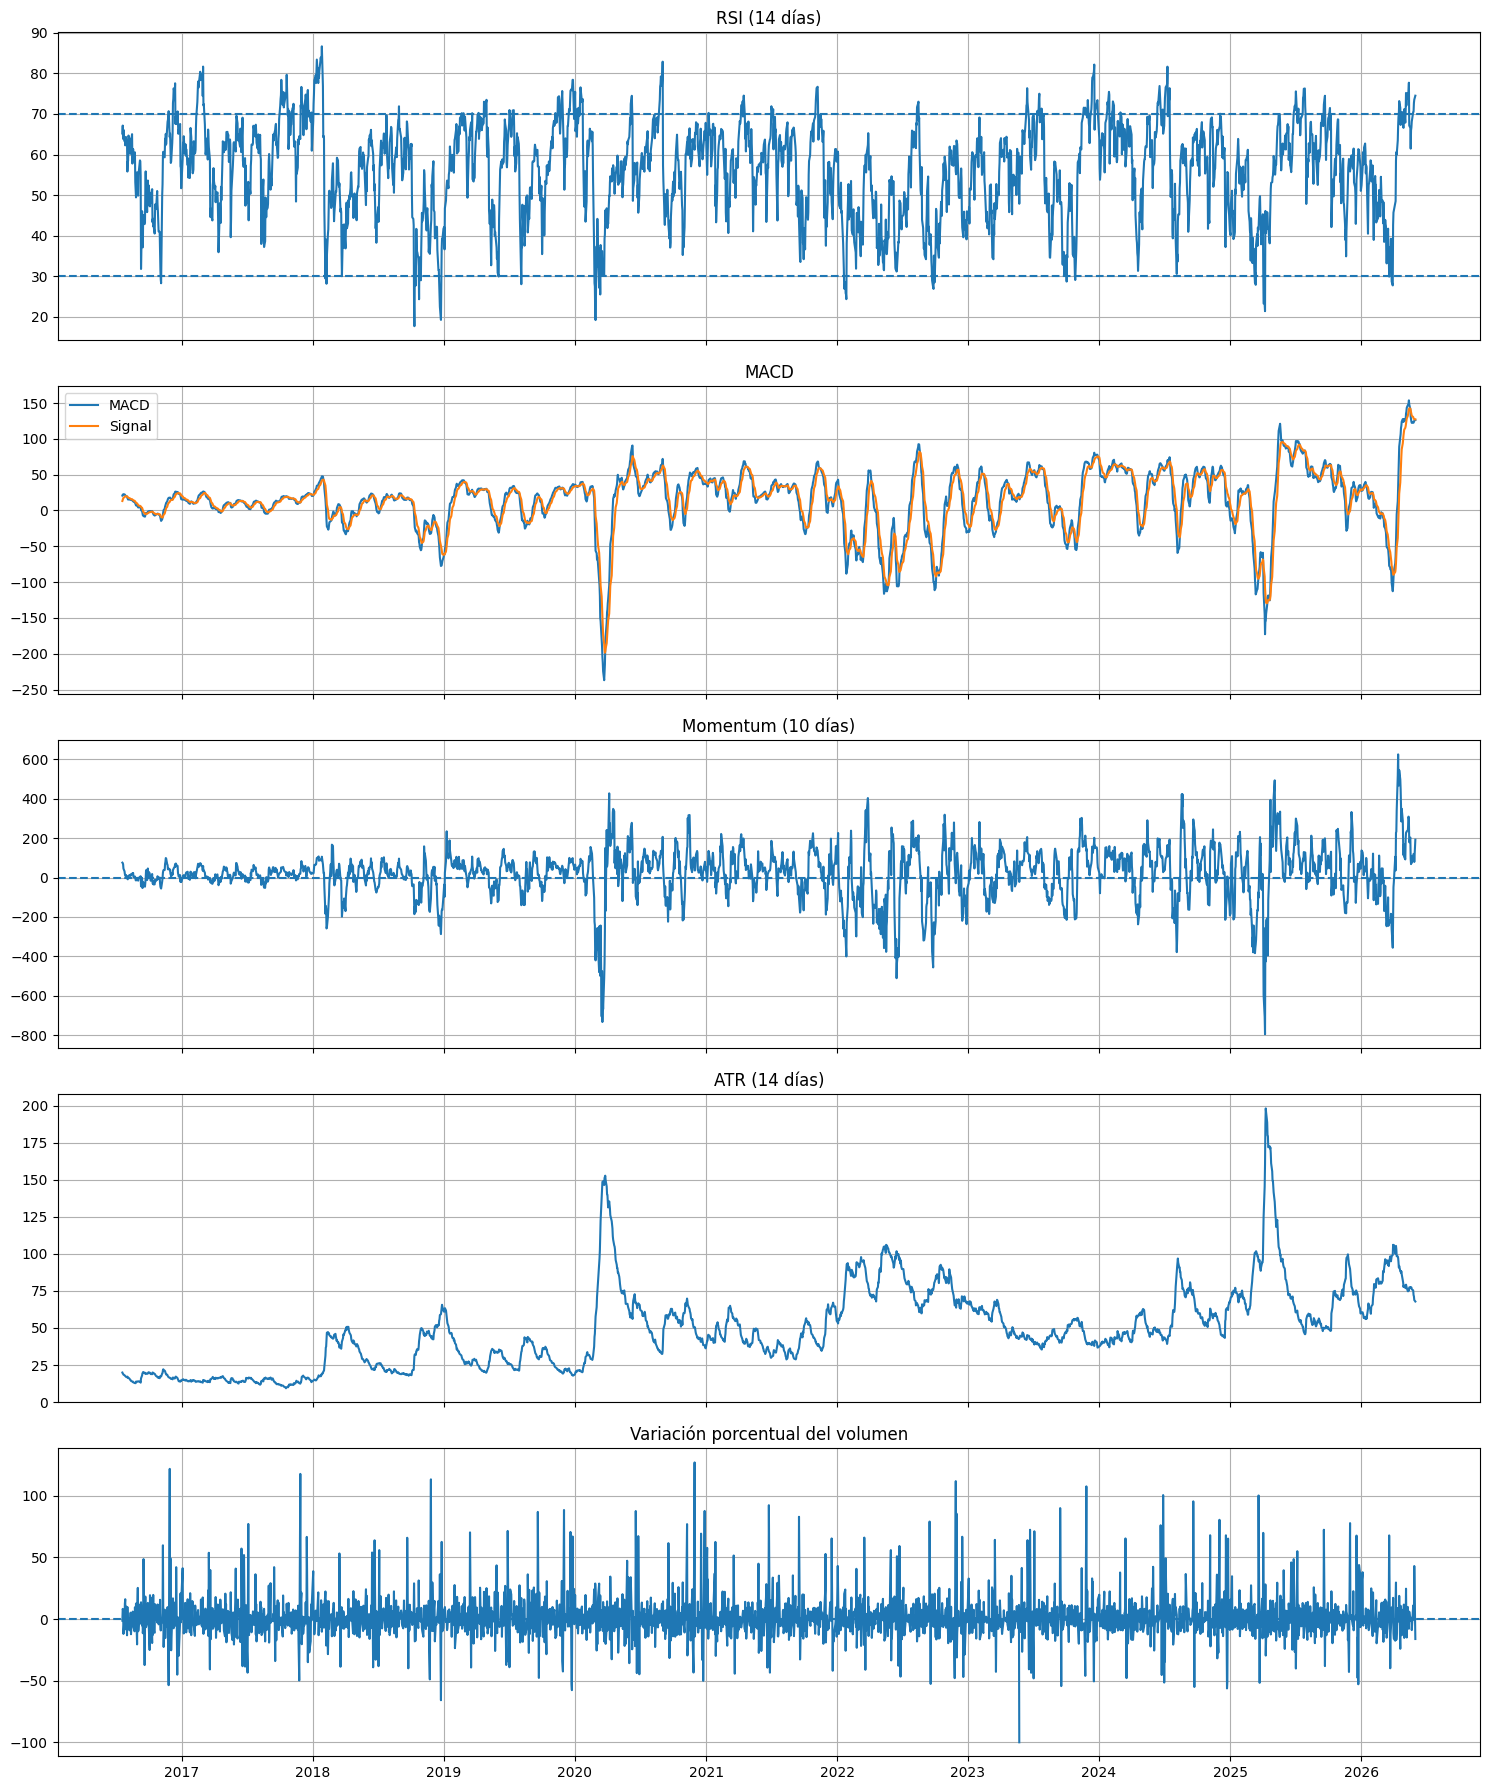

In [6]:
fig, axs = plt.subplots(
    5,
    1,
    figsize=(15,18),
    sharex=True
)

# RSI
axs[0].plot(sp500.index, sp500["RSI"])
axs[0].axhline(70, linestyle="--")
axs[0].axhline(30, linestyle="--")
axs[0].set_title("RSI (14 días)")
axs[0].grid(True)

# MACD
axs[1].plot(sp500.index, sp500["MACD"], label="MACD")
axs[1].plot(sp500.index, sp500["MACD_SIGNAL"], label="Signal")
axs[1].legend()
axs[1].set_title("MACD")
axs[1].grid(True)

# Momentum
axs[2].plot(sp500.index, sp500["Momentum"])
axs[2].axhline(0, linestyle="--")
axs[2].set_title("Momentum (10 días)")
axs[2].grid(True)

# ATR
axs[3].plot(sp500.index, sp500["ATR"])
axs[3].set_title("ATR (14 días)")
axs[3].grid(True)

# Cambio porcentual de volumen
axs[4].plot(sp500.index, sp500["Volume_Pct_Change"])
axs[4].axhline(0, linestyle="--")
axs[4].set_title("Variación porcentual del volumen")
axs[4].grid(True)

plt.tight_layout()
plt.show()

Análisis de correlaciones

--- Matriz de Correlaciones ---
Price              Log_Returns  Hist_Volatility       RSI      MACD  Momentum  \
Price                                                                           
Log_Returns           1.000000         0.009640  0.297719  0.047906  0.313837   
Hist_Volatility       0.009640         1.000000 -0.395585 -0.541694 -0.140305   
RSI                   0.297719        -0.395585  1.000000  0.722221  0.708321   
MACD                  0.047906        -0.541694  0.722221  1.000000  0.612003   
Momentum              0.313837        -0.140305  0.708321  0.612003  1.000000   
ATR                   0.008785         0.733764 -0.391392 -0.377485 -0.120290   
Volume_Pct_Change    -0.091722        -0.012419 -0.021907  0.012034 -0.024753   

Price                   ATR  Volume_Pct_Change  
Price                                           
Log_Returns        0.008785          -0.091722  
Hist_Volatility    0.733764          -0.012419  
RSI               -0.391392          -0.02

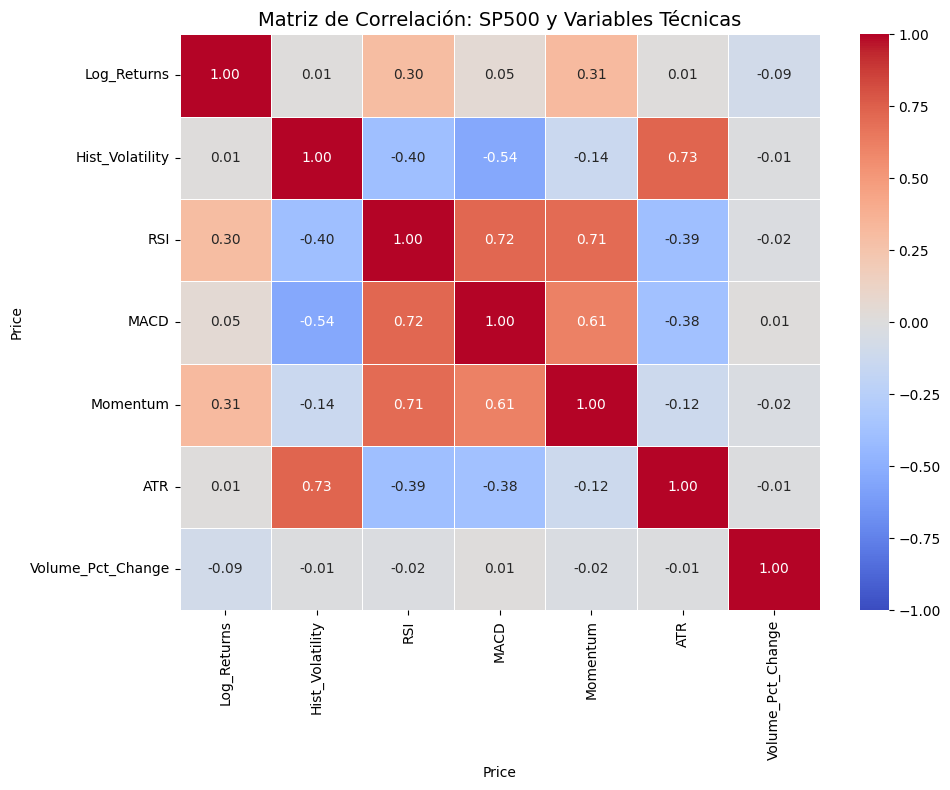

In [5]:
import numpy as np
import pandas as pd
import ta
import seaborn as sns
import matplotlib.pyplot as plt

# Asumiendo que tu DataFrame se llama 'sp500' y tiene las columnas:
# 'Open', 'High', 'Low', 'Close', 'Volume'

# ==========================
# 1. Retornos Logarítmicos
# ==========================
sp500["Log_Returns"] = np.log(sp500["Close"] / sp500["Close"].shift(1))

# ==========================
# 2. Volatilidad Histórica (20 días, anualizada)
# ==========================
sp500["Hist_Volatility"] = sp500["Log_Returns"].rolling(window=20).std() * np.sqrt(252)

# ==========================
# 3. RSI (14 días)
# ==========================
sp500["RSI"] = ta.momentum.RSIIndicator(
    close=sp500["Close"],
    window=14
).rsi()

# ==========================
# 4. MACD
# ==========================
macd = ta.trend.MACD(
    close=sp500["Close"],
    window_fast=12,
    window_slow=26,
    window_sign=9
)
sp500["MACD"] = macd.macd()
sp500["MACD_SIGNAL"] = macd.macd_signal()
sp500["MACD_HIST"] = macd.macd_diff()

# ==========================
# 5. Momentum (10 días)
# ==========================
sp500["Momentum"] = (
    sp500["Close"] - sp500["Close"].shift(10)
)

# ==========================
# 6. ATR (14 días)
# ==========================
sp500["ATR"] = ta.volatility.AverageTrueRange(
    high=sp500["High"],
    low=sp500["Low"],
    close=sp500["Close"],
    window=14
).average_true_range()

# ==========================
# 7. Variación porcentual del volumen
# ==========================
sp500["Volume_Pct_Change"] = (
    sp500["Volume"].pct_change() * 100
)

# ==========================
# 8. Limpiar datos y Calcular Matriz
# ==========================
# Eliminar NaN generados por los cálculos (ej. el MACD y la Volatilidad toman hasta 26 días en generarse)
sp500 = sp500.dropna()

# Definir la lista de columnas de interés para la correlación
columnas_correlacion = [
    "Log_Returns",
    "Hist_Volatility",
    "RSI",
    "MACD",
    "Momentum",
    "ATR",
    "Volume_Pct_Change"
]

# Crear matriz de correlaciones (Usando el coeficiente de Pearson por defecto)
matriz_corr = sp500[columnas_correlacion].corr()

# Mostrar la matriz en texto
print("--- Matriz de Correlaciones ---")
print(matriz_corr)

# ==========================
# 9. Visualización Gráfica (Heatmap)
# ==========================
plt.figure(figsize=(10, 8))
sns.heatmap(
    matriz_corr, 
    annot=True,          # Muestra el valor de correlación en la celda
    cmap="coolwarm",     # Paleta de colores (rojo para correlación positiva, azul para negativa)
    fmt=".2f",           # Redondea los valores a 2 decimales
    vmin=-1, vmax=1,     # Rango de correlación de -1 a 1
    linewidths=0.5
)
plt.title("Matriz de Correlación: SP500 y Variables Técnicas", fontsize=14)
plt.tight_layout()
plt.show()